## Graphs Processing

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# task = "LinReg"
task = "BinClass"
path = f"../scripts/results/{task}_Synth_best_params_20_by_2.csv"


# /workspace/scripts/results/BinClass_gradients_dynamics_20_by_2.csv

path_1 = f"../scripts/results/{task}_Synth_20_by_2.csv"
path_2 = f"../scripts/results/{task}_AU_14_by_2.csv"
path_3 = f"../scripts/results/{task}_Splice_287_by_3.csv"

In [10]:
df_bin = pd.read_csv(path)

# df_1 = pd.read_csv(path_1)
# df_2 = pd.read_csv(path_2)
# df_3 = pd.read_csv(path_3)

# df_1["dataset"] = ["Synthetic"] * len(df_1["epoch"])
# df_2["dataset"] = ["Australian"] * len(df_2["epoch"])
# df_3["dataset"] = ["Splice"] * len(df_2["epoch"])

# df_bin = pd.concat([df_1, df_2, df_3])
# df_linreg = pd.concat([df_3, df_4])

df_bin.head(15)


,Unnamed: 0,epoch,optimizer,lr,loss,accuracy,mode,rank,eps,X_type,avg_epoch_time,epoch_time,batch_size,data_seed
0,0,0,Shampoo,0.1,0.676284,0.533333,test,NaN,0.1,X true,0.000000,0.000000,1,10.0
1,1,0,Shampoo,0.1,0.666769,0.550000,train,NaN,0.1,X true,0.000000,0.000000,1,10.0
2,2,1,Shampoo,0.1,0.439424,0.916667,test,NaN,0.1,X true,0.272638,0.272639,1,NaN
3,3,1,Shampoo,0.1,0.379195,0.954167,train,NaN,0.1,X true,0.272638,0.272639,1,NaN
4,4,2,Shampoo,0.1,0.393900,0.950000,test,NaN,0.1,X true,0.243879,0.487758,1,NaN
5,5,2,Shampoo,0.1,0.327066,0.958333,train,NaN,0.1,X true,0.243879,0.487758,1,NaN
6,6,3,Shampoo,0.1,0.368208,0.950000,test,NaN,0.1,X true,0.230101,0.690305,1,NaN
7,7,3,Shampoo,0.1,0.297604,0.958333,train,NaN,0.1,X true,0.230101,0.690305,1,NaN
8,8,4,Shampoo,0.1,0.350705,0.950000,test,NaN,0.1,X true,0.224788,0.899151,1,NaN
9,9,4,Shampoo,0.1,0.277834,0.966667,train,NaN,0.1,X true,0.224788,0.899151,1,NaN


<Figure size 1500x1000 with 0 Axes>

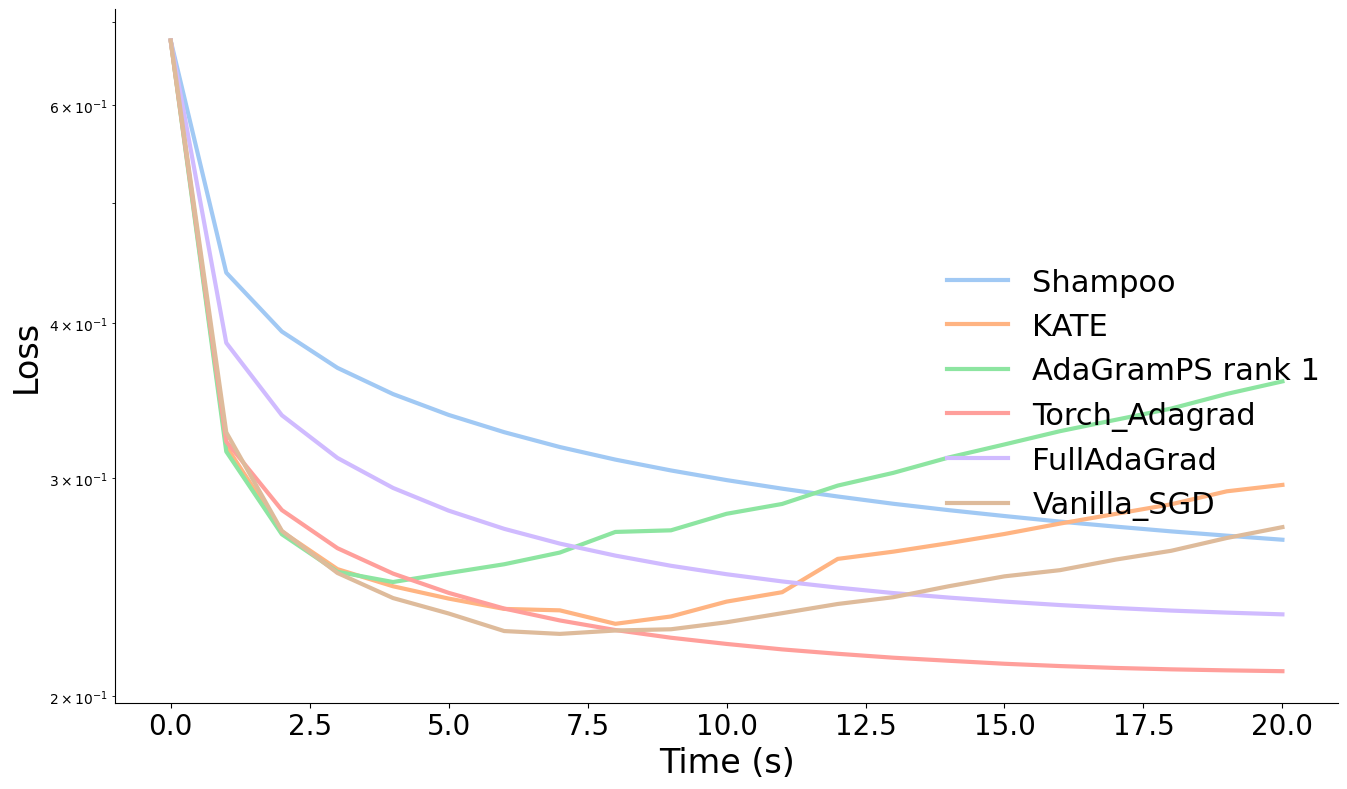

In [ ]:
import os
# torch_ada = df_bin.query("optimizer == 'AdaGramPS rank 4' and mode == 'test' and epoch < 20")
dir = "plots"

plt.figure(figsize=(15, 10))
grid = sns.FacetGrid(
    data=df_bin.query('mode == "test"'),
    # "optimizer != 'AdaGramFR_s'vd rank 2' and optimizer != 'AdaGramFR_svd rank 3'and optimizer != 'AdaGramFR_svd rank 5'"),
    # col='batch_size',
    height=8,
    
    aspect=1.2,
    sharey=True,
)



grid.map_dataframe(
    sns.lineplot,
    
    x='epoch',
    # y='avg_epoch_time',
    y='loss',
    # style='',
    # style='mode',
    hue='optimizer',
    palette='pastel',
    linewidth=3
)

# Set bigger font size for legend title and legend text
grid.add_legend(fontsize=22)

# for ax in grid.axes.flat:
#     # --- Add this line to set the x-axis limit ---
#     ax.set_xlim(0, 3.8)

# grid.fig.suptitle(f'LinReg(20, 2)', 
#                   fontsize=24,)

# grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=24)
    ax.set_ylabel(ax.get_ylabel(), fontsize=24)
    ax.tick_params(axis='x', which='major', labelsize=20)
    ax.tick_params(axis='y', which='major', labelsize=20)
    

grid.set_titles(col_template="batch_size = {col_name}")
grid.set_axis_labels("Epoch", "Loss") 
for ax in grid.axes.flat:
    ax.set_title(ax.get_title(), fontsize=24)  # Explicitly set desired fontsize

output_path = os.path.join(dir, f'Mnist_batch_64.pdf')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


In [15]:
df = df_bin[(df_bin['mode'] == 'test') & (df_bin['optimizer'].str.contains("AdaGram"))]
df = df[['accuracy', 'optimizer', 'lr', 'rank', 'batch_size', 'eps']]
df.head()

,accuracy,optimizer,lr,rank,batch_size,eps
0,0.533333,AdaGramPS rank 1,0.01,1.0,1,0.01
2,0.666667,AdaGramPS rank 1,0.01,1.0,1,0.01
4,0.666667,AdaGramPS rank 1,0.01,1.0,1,0.01
6,0.666667,AdaGramPS rank 1,0.01,1.0,1,0.01
8,0.650000,AdaGramPS rank 1,0.01,1.0,1,0.01


In [36]:
!pip install plotly 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 39.4 MB/s eta 0:00:00a 0:00:01


In [4]:

import pandas as pd
import plotly.express as px

df_grid_search = pd.read_csv("../scripts/results/BinClass_synth_grid_search_20_by_2.csv")
# 1. Load your experiment results
try:
    # This line should be adjusted to load your actual data
    df = df_grid_search[(df_grid_search['mode'] == 'test') & (df_grid_search['optimizer'].str.contains("SGD"))]
    # df = df[['accuracy', 'optimizer', 'lr', 'rank', 'batch_size', 'eps']]
except (NameError, FileNotFoundError): # More robust error handling
    # Create a dummy DataFrame if the file doesn't exist for demonstration
    data = {
        'lr': [0.01, 0.01, 0.001, 0.001, 0.05, 0.05],
        'batch_size': [32, 64, 32, 64, 32, 64],
        'eps': [1e-8, 1e-7, 1e-8, 1e-7, 1e-8, 1e-7],
        'rank': [10, 20, 10, 20, 10, 20],
        'accuracy': [0.85, 0.88, 0.91, 0.90, 0.82, 0.89]
    }
    df = pd.DataFrame(data)

# 2. Define dimensions and the performance metric
hyperparameter_dims = ['lr', 'batch_size',  'accuracy']
hyperparameter_cols = ['lr', 'batch_size']
performance_metric = 'accuracy'
time_col = 'epoch_time'

df_sorted = df.sort_values(
    by=[performance_metric, time_col], 
    ascending=[False, True]
)

# 3. Drop duplicates based on hyperparameters, keeping the first entry
#    Because of our sorting, the first entry for each group is now guaranteed
#    to be the earliest occurrence of its highest accuracy.
df_earliest_best = df_sorted.drop_duplicates(
    subset=hyperparameter_cols, 
    keep='first'
)

# 3. Create the parallel coordinates plot
fig = px.parallel_coordinates(
    df_earliest_best,
    dimensions=hyperparameter_dims,
    color=performance_metric,
    color_continuous_scale=px.colors.diverging.RdBu_r,
    labels={
        "lr": "Learning Rate",
        "batch_size": "Batch Size",
        # "eps": "Epsilon",
        # "rank": "Rank",
        "accuracy": "Accuracy"
    },
    title="Hyperparameter Optimization Analysis"
)

# 4. Update layout to make the plot taller
fig.update_layout(
    height=800  # Set the desired height of the plot in pixels
)

# 5. Display the interactive plot
fig.show()
 


In [7]:
df_sorted = df_grid_search[['epoch', 'optimizer', 'mode', 'rank', 'eps', 'lr', 'batch_size', 'accuracy', 'loss']]

df_sorted = df_sorted.sort_values(by=['loss'], ascending=[True])

# 2. Drop duplicates based on the 'optimizer' column, keeping the first entry.
#    Because of the sorting in the previous step, this first entry is guaranteed
#    to be the run with the highest accuracy, achieved at the earliest epoch.
df_best_per_optimizer = df_sorted.drop_duplicates(subset=['optimizer'], keep='first')

# Display the final resultsно 
print("The hyperparameter set for each optimizer that achieved its best loss at the earliest epoch is:")
print(df_best_per_optimizer)

The hyperparameter set for each optimizer that achieved its best loss at the earliest epoch is:
       epoch         optimizer   mode  rank   eps   lr  batch_size  accuracy  \
6425      20  AdaGramPS rank 1  train   1.0  0.10  0.1           1  0.979167   
14615     20       Vanilla_SGD  train   NaN   NaN  0.1           1  0.983333   
2855      20              KATE  train   NaN  0.01  0.1          32  0.983333   
6887      20  AdaGramPS rank 2  train   2.0  0.50  0.1           1  0.970833   
6719      20  AdaGramPS rank 3  train   3.0  0.20  0.1           1  0.970833   
6761      20  AdaGramPS rank 4  train   4.0  0.20  0.1           1  0.979167   
6803      20  AdaGramPS rank 5  train   5.0  0.20  0.1           1  0.970833   
12095     20     Torch_Adagrad  train   NaN  0.01  0.1           1  0.979167   
13649     20       FullAdaGrad  train   NaN  0.10  0.1           1  0.983333   
545       20           Shampoo  train   NaN  0.10  0.1           1  0.975000   

           loss  
6425 

In [4]:
df_long = df_bin.melt(
    id_vars=['epoch', 'dataset','optimizer', 'mode', 'batch_size'],       # columns to keep
    value_vars=['loss', 'accuracy'],    # columns to melt
    var_name='metric', value_name='value'
)

df_long.head()

,epoch,dataset,optimizer,mode,batch_size,metric,value
0,0,Synthetic,AdaGramPS rank 1,test,1,loss,0.676284
1,0,Synthetic,AdaGramPS rank 1,train,1,loss,0.666769
2,1,Synthetic,AdaGramPS rank 1,test,1,loss,0.315198
3,1,Synthetic,AdaGramPS rank 1,train,1,loss,0.236529
4,2,Synthetic,AdaGramPS rank 1,test,1,loss,0.270308


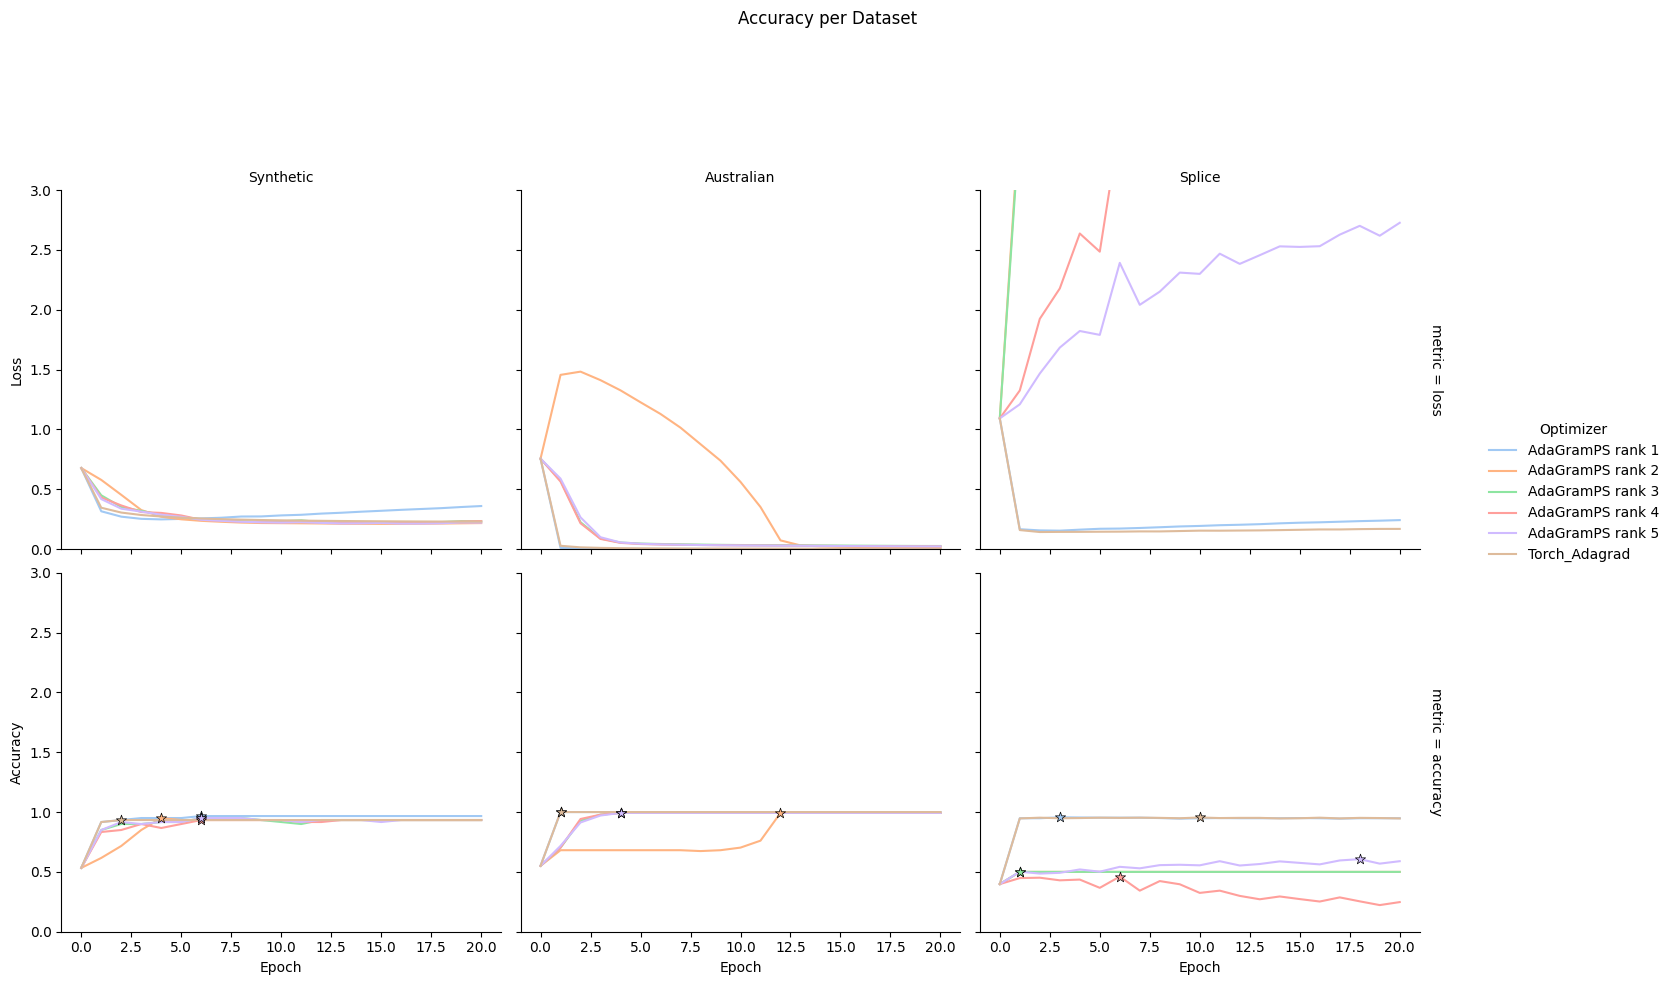

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume df_long is already loaded

# Filter your data for mode == 'test' and batch_size == 1
df_plot = df_long.query('mode == "test" and batch_size == 1')

def mark_best_accuracy(data, **kwargs):
    # Only process the facet with 'accuracy'
    if data['metric'].iloc[0] == 'accuracy':
        # Find best point for each optimizer
        best_points = data.loc[data.groupby(['optimizer'])['value'].idxmax()]
        color = kwargs.get("color", "C0")
        plt.scatter(
            best_points['epoch'],
            best_points['value'],
            color=color,
            marker='*',
            s=60,
            edgecolor='black',
            linewidth=0.5,
            zorder=10
        )

# Draw the grid as usual
g = sns.FacetGrid(
    df_plot,
    row='metric', col='dataset',
    hue='optimizer', palette='pastel',
    margin_titles=True, height=5
)
g.map(sns.lineplot, 'epoch', 'value')

# Set y-axis for accuracy only
g.set_axis_labels('Epoch', 'Value')

g.axes[0, 0].set_ylim(0, 3)


for ax, metric in zip(g.axes[:,0], g.row_names):
    if metric == 'accuracy':
        ax.set_ylabel('Accuracy')
        # ax.set_ylim(0, 1.1)   # fixed y-limits for accuracy row
    else:
        ax.set_ylabel('Loss')
        # ax.set_ylim(auto=True)
        # ax.set_ylim(0, 10)  # OR: do nothing for loss, keeps autoscale

g.map_dataframe(mark_best_accuracy)

g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Accuracy per Dataset')
g.add_legend(title='Optimizer')

plt.show()


In [58]:
g.row_names

['loss', 'accuracy']

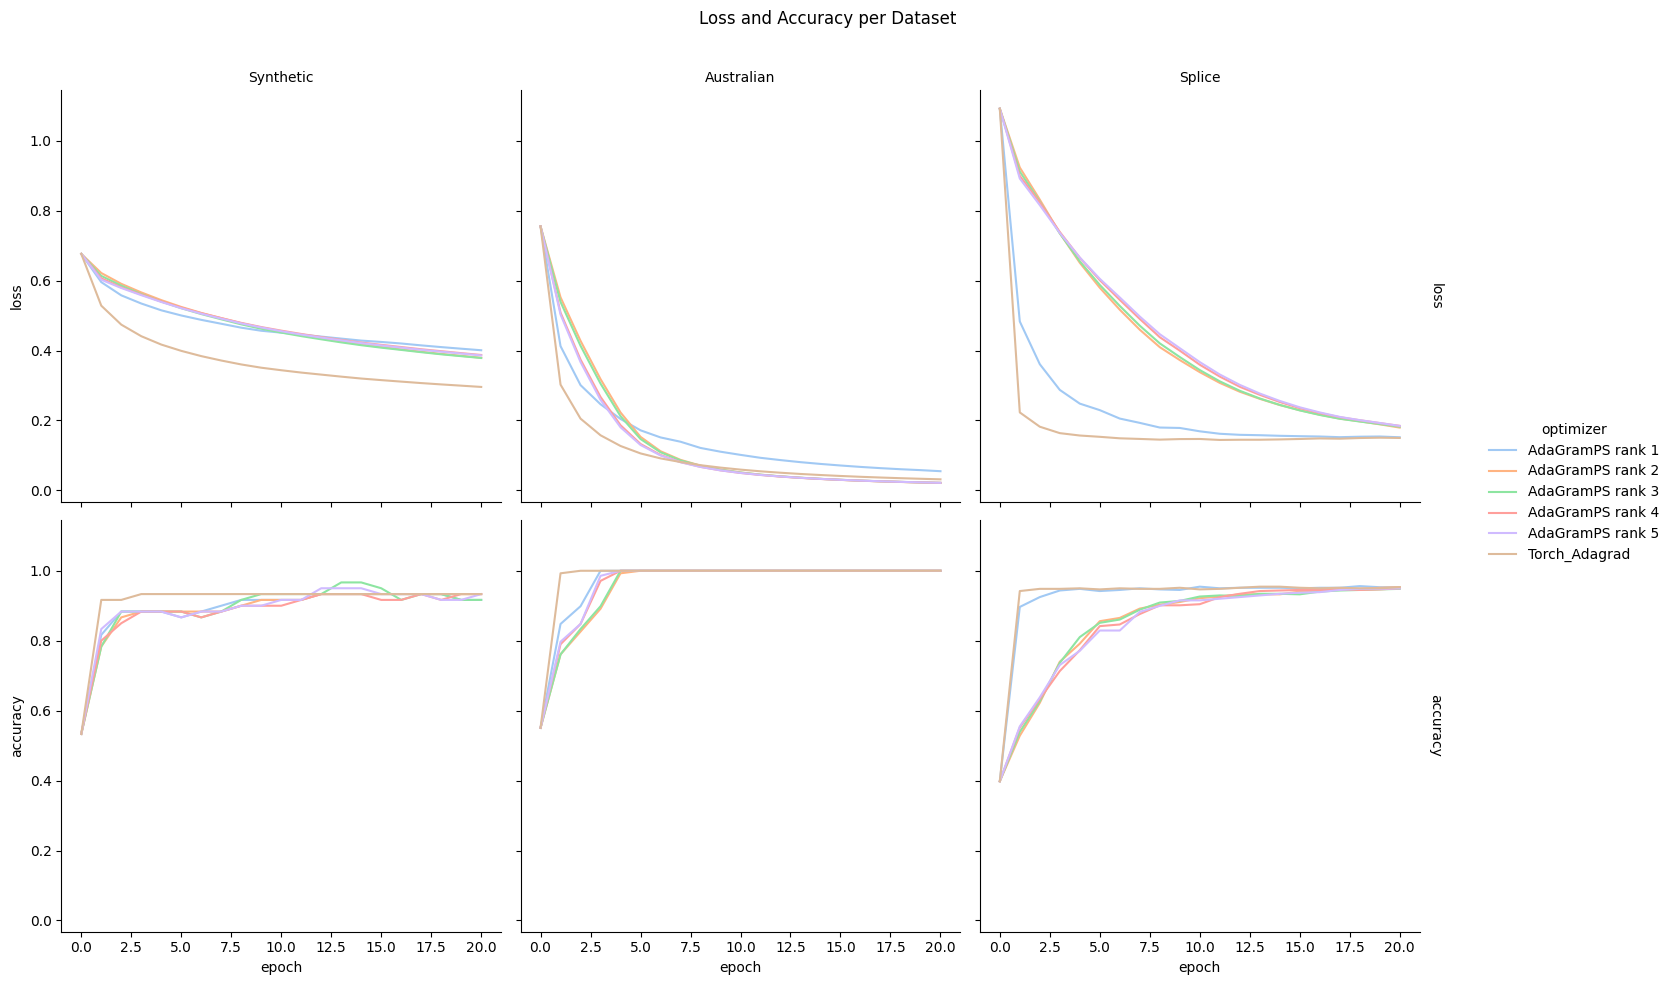

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df_long.query('mode == "test" and batch_size == 32'),
    row='metric', col='dataset',
    hue='optimizer', palette='pastel',
    margin_titles=True, height=5
)
g.map(sns.lineplot, 'epoch', 'value')
g.set_axis_labels('epoch', '')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Loss and Accuracy per Dataset')

for ax, metric in zip(g.axes[:,0], ['loss', 'accuracy']):
    ax.set_ylabel(metric)

g.add_legend()  # <-- Add this to show the hue variable legend

plt.show()


In [23]:
df_bin = pd.read_csv("../scripts/results/BinClass_MNIST_all_ranks_784_by_10.csv")
df_bin.head()

,Unnamed: 0,epoch,optimizer,lr,loss,accuracy,mode,rank,eps,X_type,avg_epoch_time,epoch_time,batch_size,data_seed
0,0,0,AdaGramPS rank 1,0.1,2.334469,0.083833,test,1.0,0.1,X true,0.000000,0.000000,32,10.0
1,1,0,AdaGramPS rank 1,0.1,2.333639,0.079917,train,1.0,0.1,X true,0.000000,0.000000,32,10.0
2,2,1,AdaGramPS rank 1,0.1,0.569475,0.866667,test,1.0,0.1,X true,4.587944,4.587883,32,NaN
3,3,1,AdaGramPS rank 1,0.1,0.566700,0.863875,train,1.0,0.1,X true,4.587944,4.587883,32,NaN
4,4,2,AdaGramPS rank 1,0.1,0.446945,0.881833,test,1.0,0.1,X true,4.669970,4.751410,32,NaN


/tmp/ipykernel_3568842/3732820159.py:13: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_3568842/3732820159.py:17: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_3568842/3732820159.py:55: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color*

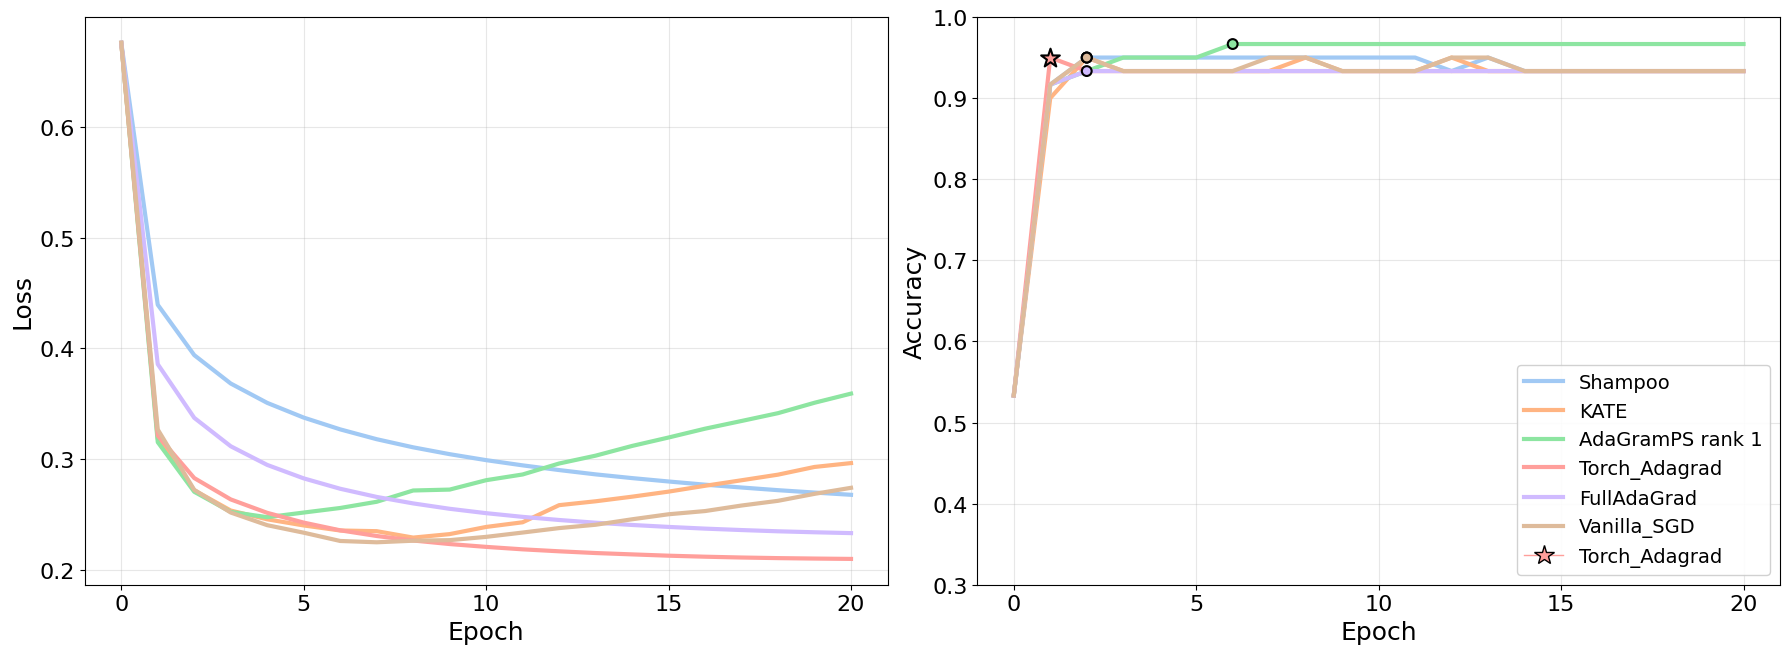

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
import os
import numpy as np

dir = './plots'

# Your existing data preparation code...
df_test = df_bin[df_bin['mode'] == 'test']
df_test = df_test
best_accuracies = df_test.groupby('optimizer').apply(
    lambda g: g.loc[g['accuracy'].idxmax()]
).reset_index(drop=True)

best_losses = df_test.groupby('optimizer').apply(
    lambda g: g.loc[g['loss'].idxmin()]
).reset_index(drop=True)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# Color mapping
optimizers = df_test['optimizer'].unique()
palette = sns.color_palette('pastel', len(optimizers))
color_map = {opt: color for opt, color in zip(optimizers, palette)}

# Plot loss over epochs (left subplot)
sns.lineplot(data=df_test, x='epoch', y='loss', hue='optimizer', linewidth=3,
             markers=True, legend=False, palette=color_map, ax=axes[0])


# axes[0].set_title('Loss over Epochs', fontsize=22)
axes[0].set_xlabel('Epoch', fontsize=18)
axes[0].set_ylabel('Loss', fontsize=18)
# axes[0].set_yscale('log')  # Keep log scale for loss
axes[0].grid(True, alpha=0.3)

# for ax in grid.axes.flat:
    # --- Add this line to set the x-axis limit ---

# Plot accuracy over epochs (right subplot)
sns.lineplot(data=df_test, x='epoch', y='accuracy', hue='optimizer', linewidth=3,
             markers=True, palette=color_map, ax=axes[1])

# Add scatter points
sns.scatterplot(data=best_accuracies.query("optimizer != 'Torch_Adagrad'"), x='epoch', y='accuracy', hue='optimizer', 
                s=50, edgecolor='black', linewidth=1.5, legend=False, zorder=5, palette=color_map, ax=axes[1])

# Add star marker for Torch_Adagrad
torch_adagrad_best_row = best_accuracies[best_accuracies['optimizer'] == 'Torch_Adagrad']
if not torch_adagrad_best_row.empty:
    torch_adagrad_best = torch_adagrad_best_row.iloc[0]
    axes[1].scatter(torch_adagrad_best['epoch'], torch_adagrad_best['accuracy'], 
                   s=200, marker='*', c=color_map['Torch_Adagrad'], edgecolors='black', linewidths=1.5, 
                   zorder=10)

# axes[1].set_title('Accuracy over Epochs', fontsize=22)
axes[1].set_xlabel('Epoch', fontsize=18)
axes[1].set_ylabel('Accuracy', fontsize=18)


# FIX 1: Remove log scale from accuracy plot
# axes[1].set_yscale('log')  # Comment this out or remove it

# FIX 2: Set better y-axis limits for accuracy
axes[1].set_ylim(0.5, 1.0)  # Adjust range to show meaningful differences

# FIX 3: Improve tick formatting
for ax in axes:
    ax.tick_params(axis='x', which='major', labelsize=16)
    ax.tick_params(axis='y', which='major', labelsize=16)
    
# FIX 4: Set specific tick locations for better readability
# axes[0].set_xticks(range(0, 21, 5))  # Ticks every 5 epochs
axes[1].set_xticks(range(0, 21, 5))
axes[1].set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])  # Clear accuracy intervals

# Legend with better positioning
handles, labels = axes[1].get_legend_handles_labels()
star_handle = Line2D([0], [0], marker='*', color=color_map['Torch_Adagrad'], label='Torch_Adagrad',
                      markeredgecolor='black', markersize=15, linewidth=1)
handles.append(star_handle)
labels.append('Torch_Adagrad')

# FIX 5: Better legend positioning
axes[1].legend(handles=handles, labels=labels, fontsize=14, 
               loc='lower right', framealpha=0.9)  # Adjust location as needed

axes[1].grid(True, alpha=0.3)
output_path = os.path.join(dir, 'psi_bin_classification.pdf')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()



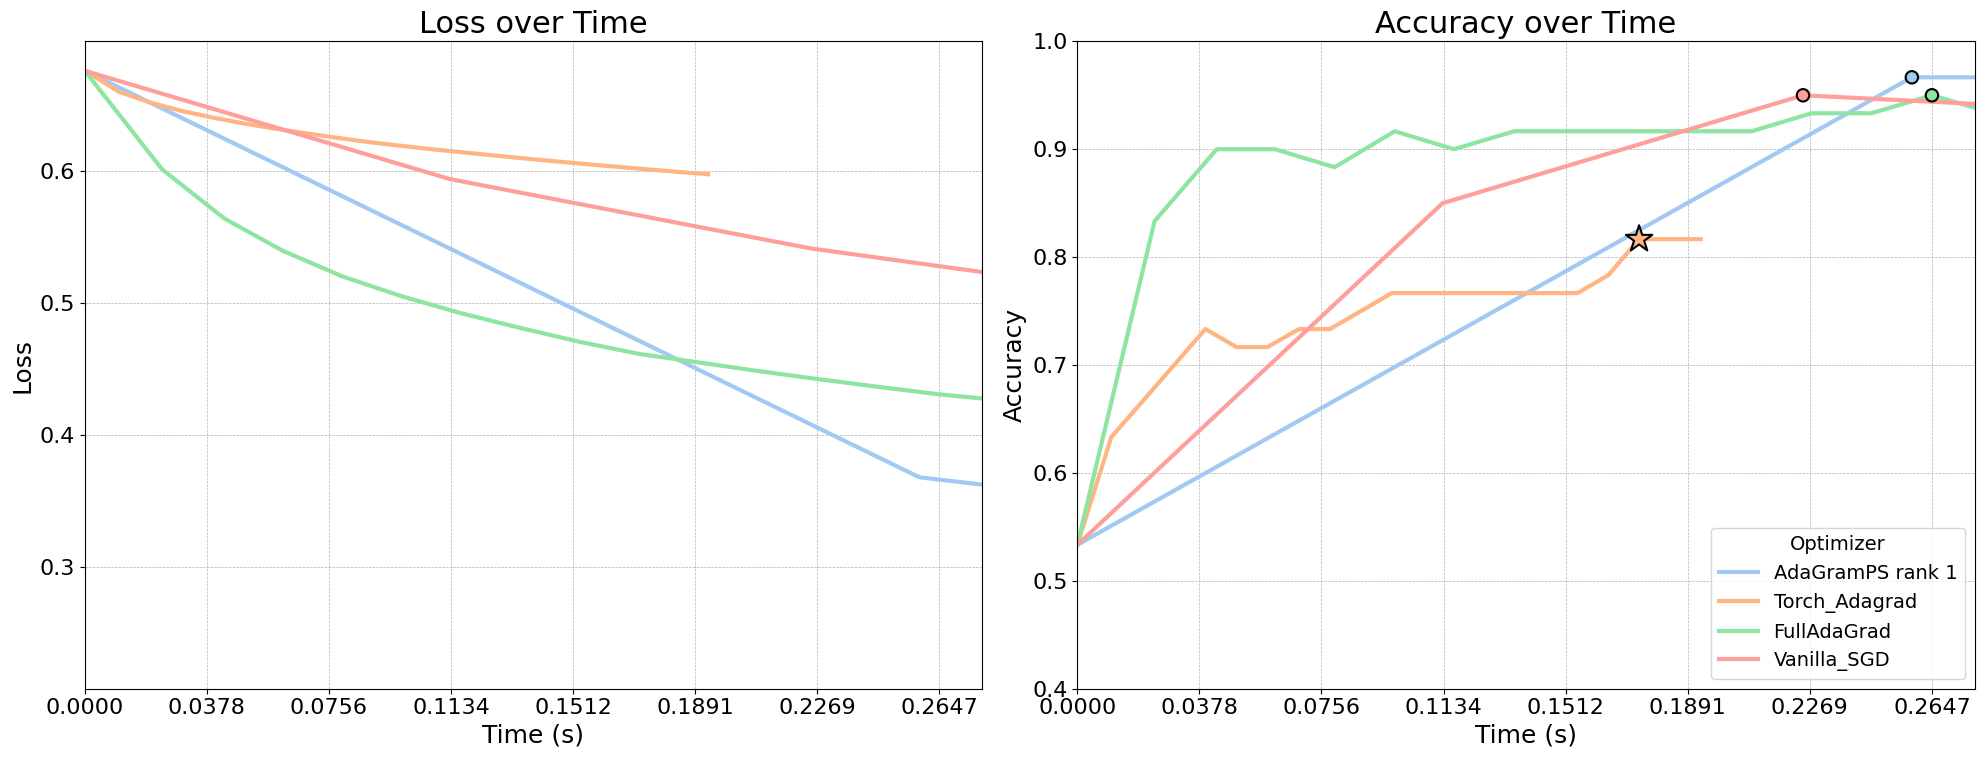

In [83]:
dir = './plots'
os.makedirs(dir, exist_ok=True)

# Data preparation
df_test = df_bin[df_bin['mode'] == 'test']
best_accuracies = df_test.loc[df_test.groupby('optimizer')['accuracy'].idxmax()].reset_index(drop=True)

# Calculate dynamic axis limits
min_time_limit = df_test['epoch_time'].min()
max_time_limit = best_accuracies['epoch_time'].max()

# --- Plotting Setup ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=False)

# Define optimizers and create maps for color, markers, and sizes
optimizers = df_test['optimizer'].unique()
palette = sns.color_palette('pastel', len(optimizers))
color_map = {opt: color for opt, color in zip(optimizers, palette)}
marker_map = {opt: 'o' for opt in optimizers}
marker_map['Torch_Adagrad'] = '*'

# --- KEY CHANGE: Create a size map for the markers ---
# Assign a small size to circles and a large size to the star
sizes_map = {opt: 80 for opt in optimizers}  # Smaller circles
sizes_map['Torch_Adagrad'] = 400            # Larger star

# --- Left Subplot: Loss vs. Time ---
sns.lineplot(data=df_test, x='epoch_time', y='loss', hue='optimizer', linewidth=3,
             markers=True, legend=False, palette=color_map, ax=axes[0])
axes[0].set_title('Loss over Time', fontsize=22)
axes[0].set_xlabel('Time (s)', fontsize=18)
axes[0].set_ylabel('Loss', fontsize=18)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].set_xlim(min_time_limit, max_time_limit * 1.05)
axes[0].set_xticks(np.linspace(min_time_limit, max_time_limit, 8))

# --- Right Subplot: Accuracy vs. Time ---
sns.lineplot(data=df_test, x='epoch_time', y='accuracy', hue='optimizer', linewidth=3,
             markers=True, palette=color_map, ax=axes[1])

# Corrected scatterplot call using the new sizes_map
sns.scatterplot(data=best_accuracies, x='epoch_time', y='accuracy', hue='optimizer', 
                s=[sizes_map[opt] for opt in best_accuracies['optimizer']], #<-- Apply size map here
                edgecolor='black', linewidth=1.5, legend=False, 
                zorder=5, palette=color_map, ax=axes[1], style='optimizer', 
                markers=marker_map)

axes[1].set_title('Accuracy over Time', fontsize=22)
axes[1].set_xlabel('Time (s)', fontsize=18)
axes[1].set_ylabel('Accuracy', fontsize=18)
axes[1].set_ylim(0.4, 1.0)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].set_xlim(min_time_limit, max_time_limit * 1.05)
axes[1].set_xticks(np.linspace(min_time_limit, max_time_limit, 8))
axes[1].set_yticks(np.arange(0.4, 1.01, 0.1))

# --- Tick Formatting ---
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=16)

# --- Legend Handling ---
handles, labels = axes[1].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
axes[1].legend(unique_labels.values(), unique_labels.keys(), 
               fontsize=14, loc='lower right', title='Optimizer', title_fontsize='14')

# --- Final Save and Show ---
output_path = os.path.join(dir, 'psi_bin_classification_fixed_time.pdf')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(output_path, dpi=300)
plt.show()


NameError: name 'df_bin' is not defined

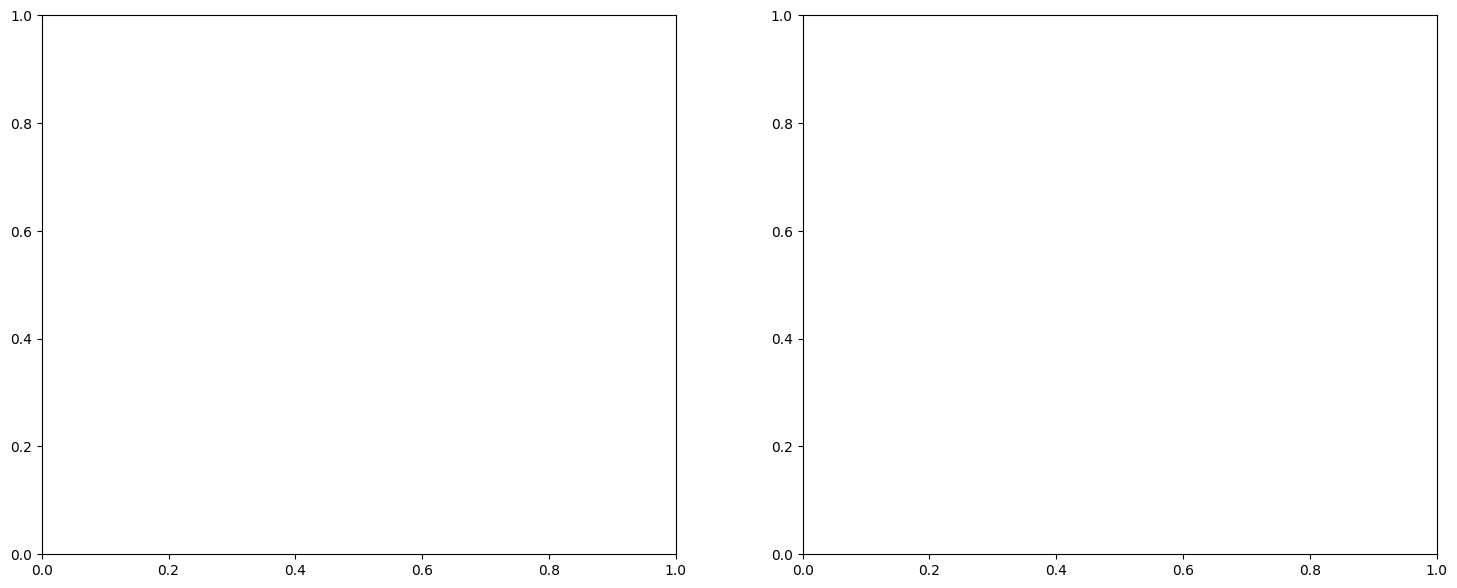

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame with 'loss' and 'accuracy' columns
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# Plot loss over epochs
sns.lineplot(
    data=df_bin.query('mode == "test" and rank == 4'), 
    x='epoch', y='loss', hue='optimizer', 
    palette='pastel', linewidth=1.5, ax=axes[0]
)
# axes[0].set_title('Loss over Epochs', fontsize=20)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch', fontsize=16)
axes[0].set_ylabel('Loss', fontsize=16)

# Plot accuracy over epochs
sns.lineplot(
    data=df_bin.query('mode == "test" and rank == 4'),
    x='epoch', y='accuracy', hue='optimizer', 
    palette='pastel', linewidth=1.5, ax=axes[1]
)
# axes[1].set_title('Accuracy over Epochs', fontsize=20)
axes[1].set_xlabel('Epoch', fontsize=16)
axes[1].set_ylabel('Accuracy', fontsize=16)

# Adjust legend to only appear once on the right plot
axes[1].legend(title='Optimizer', fontsize=12, title_fontsize=14)

# Set main title
plt.suptitle('Binary Classification (20, 2)', fontsize=24)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.savefig('binclassification_plots.pdf', format='pdf', bbox_inches='tight')

plt.show()


## Matrix G evolution

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import re

# Directory containing G matrix files
matrix_dir = "../scripts/matrix_G/"
matrix_out_dir = "../scripts/matrix_G_pngs/"

def numerical_key(filename):
    # Extract numbers as integers; returns (inf,) if no number is found
    numbers = re.findall(r'\d+', os.path.basename(filename))
    return tuple(map(int, numbers)) if numbers else (float('inf'),)

# Find all .pt files in the directory
file_pattern = os.path.join(matrix_dir, "*.pt")
files = glob.glob(file_pattern)
files.sort(key=numerical_key)  # Sort for chronological order

print(f"Found {len(files)} G matrix files to process...")

# Process each file
for filename in files[:100]:
    try:
        # Extract just the filename without path for display
        base_filename = os.path.basename(filename)
        print(f"Processing: {base_filename}")
        
        # Load G matrix
        G_matrix = torch.load(filename, map_location='cpu')
        
        # Convert to numpy array for plotting
        G_numpy = G_matrix.numpy()
        
        # Create heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(G_numpy, cmap='viridis', aspect='auto')
        plt.colorbar(label='Values')
        
        # Extract epoch info from filename for better title
        if 'epoch_' and 'batch_' in base_filename:
            epoch_info = base_filename.split('epoch_')[1].split('_')[0]
            batch_info = base_filename.split('batch_')[1].split('_')[0]

            title = f'Heatmap of G Matrix - Epoch {epoch_info}, step {batch_info}'
        else:
            title = f'Heatmap of G Matrix - {base_filename}'
        
        plt.title(title)
        plt.xlabel('Columns')
        plt.ylabel('Rows')
        
        # Create output filename (replace .pt with .png)
        output_filename = base_filename.replace('.pt', '.png')
        output_path = os.path.join(matrix_out_dir, output_filename)
        
        # Save the plot as PNG
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()  # Close the figure to free memory
        
        print(f"Saved: {output_filename}")
        
    except Exception as e:
        print(f"Error processing {base_filename}: {str(e)}")
        continue

print("Processing complete!")


Found 401 G matrix files to process...
Processing: G_matrix_epoch_0_adagram_task_BinClass.pt
Saved: G_matrix_epoch_0_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_0_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_0_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_1_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_1_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_2_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_2_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_3_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_3_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_4_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_4_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_5_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_5_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_6_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_6_adagram_task_BinClass.png
Processing: G_mat

In [3]:
from PIL import Image
import glob
import os


def create_gif_from_pngs(pattern="*.png", output="output.gif", directory=".", duration=500, optimize=True):
    """Create GIF from PNG files matching the pattern in a specific directory"""
    
    # Construct full pattern with directory path
    full_pattern = os.path.join(directory, pattern)
    files = glob.glob(full_pattern)
    print(f"Looking in: {full_pattern}")
    print(f"Found files: {files}")
    

    files.sort(key=numerical_key)
    
    if not files:
        print(f"No files found matching pattern: {full_pattern}")
        return
    
    # Load images
    images = [Image.open(f) for f in files]
    
    # Create output path in the same directory
    output_path = os.path.join(directory, output)
    
    # Create GIF
    images[0].save(
        output_path,
        save_all=True,
        append_images=images[1:],
        duration=duration,
        loop=0,
        optimize=optimize
    )
    
    print(f"GIF created: {output_path}")
    print(f"Frames: {len(images)}")

# Usage for your specific case
matrix_dir = "../scripts/matrix_G_pngs/"
create_gif_from_pngs("G_matrix_epoch_*.png", "matrix_evolution.gif", matrix_dir, duration=800)
create_gif_from_pngs("*.png", "all_matrices.gif", matrix_dir)


Looking in: ../scripts/matrix_G_pngs/G_matrix_epoch_*.png
Found files: ['../scripts/matrix_G_pngs\\G_matrix_epoch_0_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_0_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_10_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_11_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_12_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_13_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_14_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_15_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_16_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_17_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_18_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_bat

In [15]:
# df_1 = pd.read_csv('results/loggs/nosvd_adagram_logs.csv')
# df_1["method"] = ["nosvd"] * len(df_1['lr'])

# df_2 = pd.read_csv('results/loggs/svd_adagram_logs_10.csv')
# df_2["method"] = ["svd"] * len(df_2['lr'])

# df_3 = pd.read_csv('results/loggs/psi_adagram_logs.csv')
# df_3["method"] = ["psi"] * len(df_3['lr'])

df_4 = pd.read_csv('results/loggs/svd_adagram_logs_1000.csv')
df_4["method"] = ["vanila"] * len(df_4['lr'])

df = pd.concat([df_4])


In [16]:
df = df.reset_index(drop=True)

## Loggs Statistics

In [126]:
import pandas as pd
import glob
import os
import re

def extract_metadata(filename):
    # Remove directory and extension
    base = os.path.basename(filename)
    name, _ = os.path.splitext(base)
    # Match optimizer and rank (e.g., nosvd_adagram_logs_2)
    match = re.match(r'([a-zA-Z]+)_adagram_logs_(\d+)', name)
    if match:
        optimizer = match.group(1)
        rank = int(match.group(2))
    elif name == 'adagram_vanila':
        optimizer = 'vanilla'
        rank = None
    else:
        print(name)
        optimizer = 'unknown'
        rank = None
    return optimizer, rank

csv_files = glob.glob('../scripts/results/loggs/*.csv')
print(csv_files)

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    optimizer, rank = extract_metadata(file)
    df['method'] = optimizer
    df['rank'] = rank
    dfs.append(df)

df_logs = pd.concat(dfs, ignore_index=True)


['../scripts/results/loggs\\adagram_full_adagrad.csv', '../scripts/results/loggs\\adagram_logs.csv']
adagram_full_adagrad
adagram_logs


C:\Users\tanya\AppData\Local\Temp\ipykernel_3556\76817871.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_logs = pd.concat(dfs, ignore_index=True)


In [127]:
df_logs.head(10)

,step,param_id,grad_norm,grad_std,beta,lr,error_norm,rank_U,rank_V,max_U,...,max_V,min_V,U_shape_0,U_shape_1,V_shape_0,V_shape_1,method,rank,error_norm_sqrt,error_svd
0,1,0,0.296793,0.047525,0.010150,0.1,1.305431e-07,1,1,0.031038,...,3.058051,-3.058052,40,1,40,1,unknown,None,1.489215e-06,0.0
1,1,1,0.621876,0.621876,0.002454,0.1,1.215315e-07,1,1,0.034131,...,13.905581,-13.905578,2,1,2,1,unknown,None,4.173457e-07,0.0
2,2,0,0.589780,0.094440,0.002798,0.1,4.061235e-07,2,2,0.031038,...,8.018862,-8.018860,40,2,40,2,unknown,None,1.640340e-01,0.0
3,2,1,0.786835,0.786834,0.237631,0.1,5.058030e-07,2,1,0.212329,...,13.905581,-13.905578,2,2,2,2,unknown,None,5.838632e-07,0.0
4,3,0,0.417742,0.066892,0.007681,0.1,6.821674e-07,3,3,0.034629,...,8.018862,-8.018860,40,3,40,3,unknown,None,2.221021e-01,0.0
5,3,1,0.545145,0.545145,0.410979,0.1,2.143909e-07,2,1,0.212329,...,13.905581,-13.905578,2,3,2,3,unknown,None,3.910181e-06,0.0
6,4,0,0.747261,0.119657,0.003344,0.1,1.068096e-06,4,4,0.034629,...,8.018862,-8.018860,40,4,40,4,unknown,None,1.097406e-01,0.0
7,4,1,0.651999,0.651999,0.403631,0.1,2.412969e-07,2,1,0.212329,...,13.905581,-13.905578,2,4,2,4,unknown,None,2.040443e-06,0.0
8,5,0,0.318926,0.051069,0.013376,0.1,1.029970e-06,5,5,0.034629,...,8.018862,-8.018860,40,5,40,5,unknown,None,1.474491e-01,0.0
9,5,1,0.502910,0.502910,0.451078,0.1,1.533394e-07,2,1,0.212329,...,13.905581,-13.905578,2,5,2,5,unknown,None,6.497063e-07,0.0


c:\Users\tanya\mambaforge\envs\data-science-intro\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\tanya\mambaforge\envs\data-science-intro\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


<Figure size 1500x800 with 0 Axes>

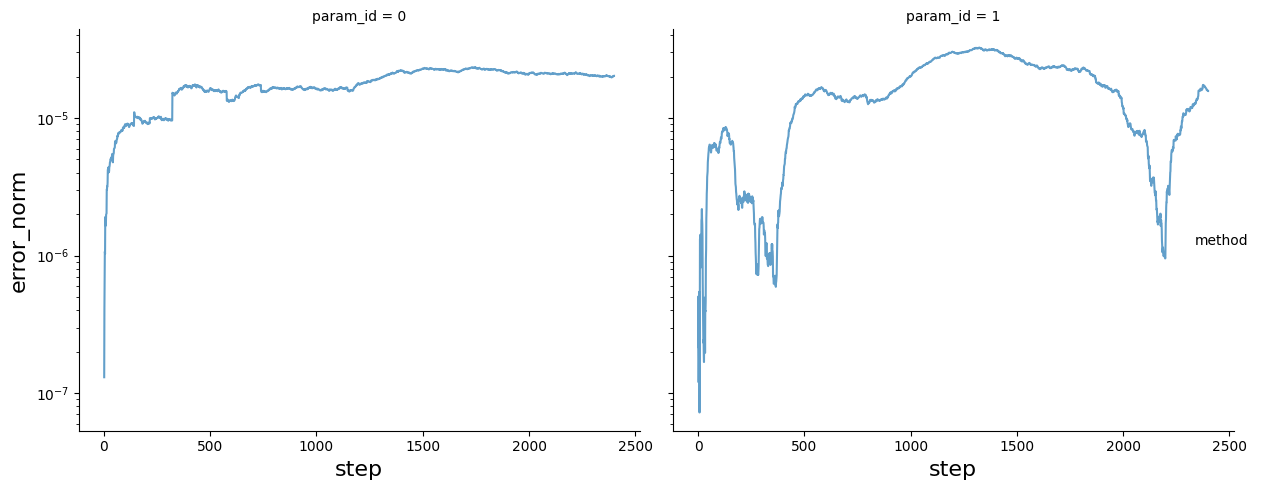

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df_logs,
    col='param_id',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='step',
    # y='avg_epoch_time',
    y='error_norm',
    # style='method',
    # hue='rank',
    palette='pastel',
    alpha = 0.7,
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend(title='method', title_fontsize='15', fontsize='12')

# grid.fig.suptitle(f'LinRegression({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="param_id = {col_name}", fontsize=20)

plt.tight_layout()
plt.show()